# 商城销售订单数据统计分析

来源：黑马程序员 PPT 练习 —— 某连锁店销售订单统计分析。

**4 个需求**：
1. 统计每天销售额的变化（折线图）
2. 统计对比不同城市的累计销售数量（柱状图）
3. 统计不同产品类型对应的订单比例（饼图）
4. 统计不同支付方式对应的订单比例（饼图）

数据：`data/sales02.csv`

## 0. 准备工作：导入库 + 加载数据 + 数据清洗

,订单号,产品类别,产品名称,销售数量,单价,客户所在城市,支付方式,订单日期
0,6805677496,家居用品,枕头,10,199,合肥,支付宝,2025-06-01
1,5857234132,食品,海苔,5,29,天津,现金,2025-06-01
2,5888085059,电子产品,智能音箱,5,399,福州,微信支付,2025-06-01
3,6823473137,食品,面包,3,29,北京,银行卡,2025-06-02
4,6801664364,食品,薯片,2,19,NaN,微信支付,2025/06/02


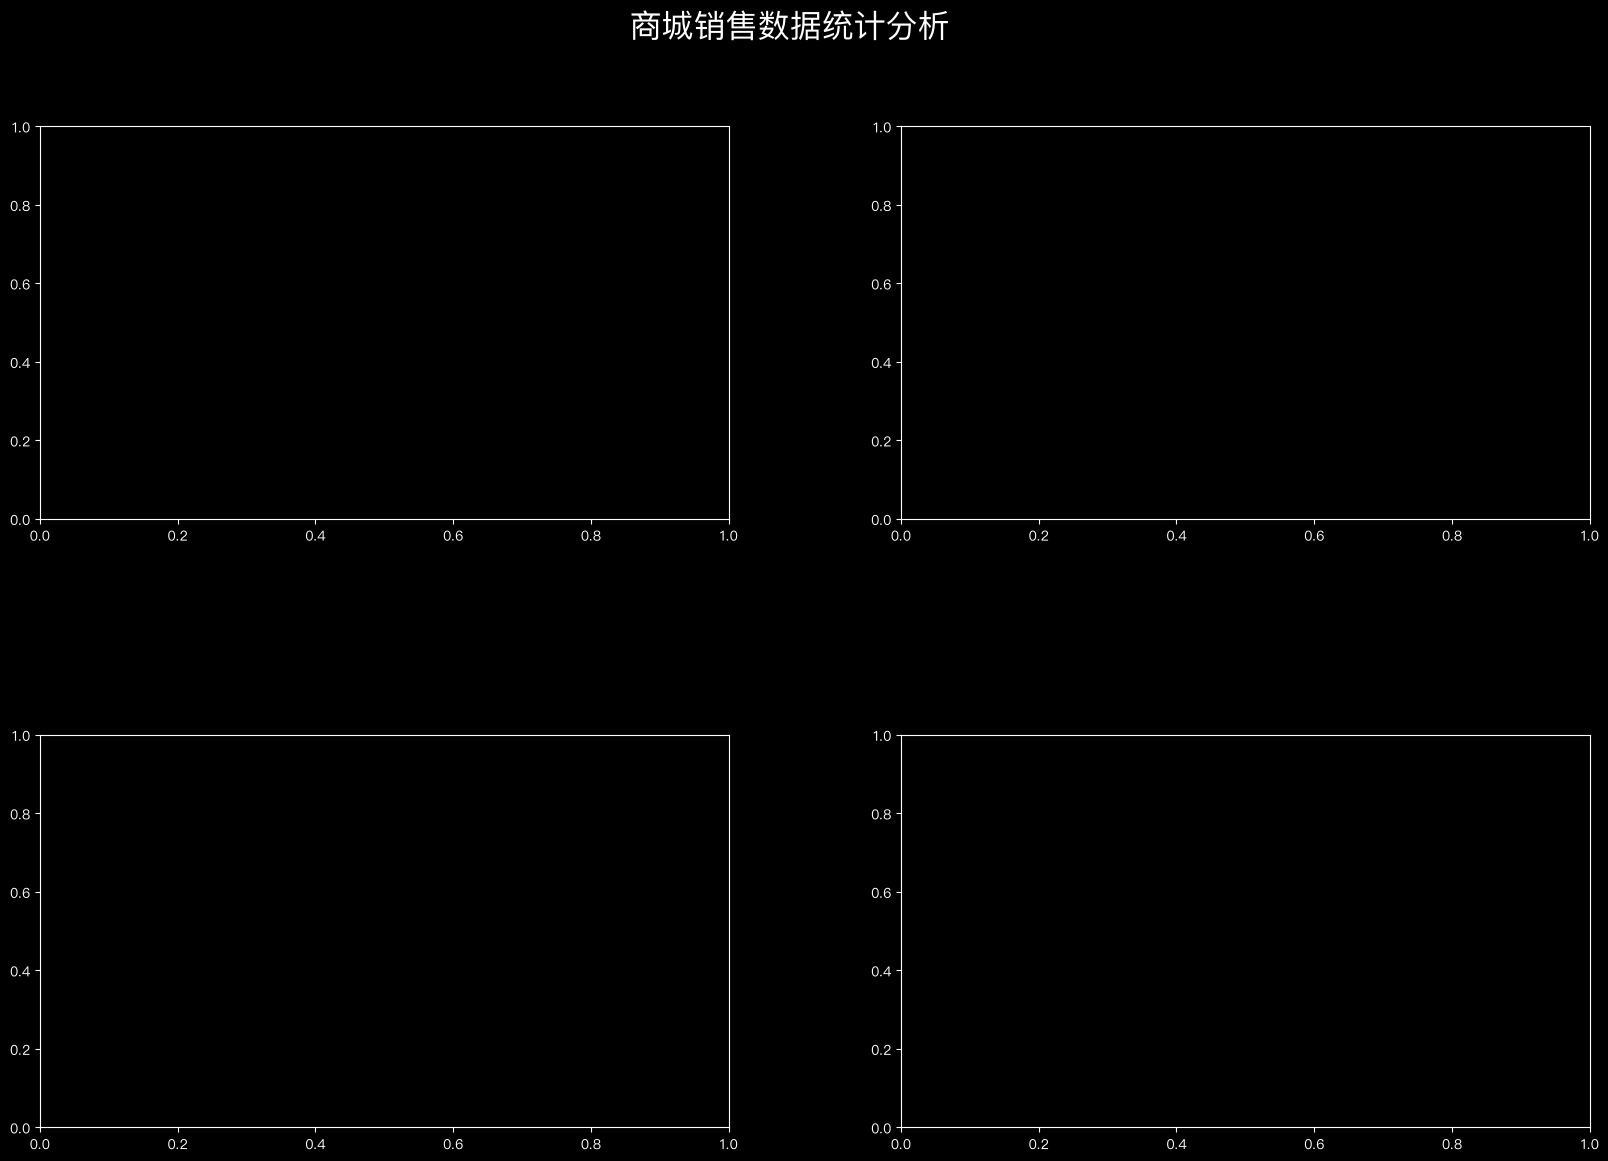

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axisartist import Axes

plt.rcParams['font.sans-serif'] = ['PingFang SC']  # macOS 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 负号不显示成方块

# 创建画布：2x2 子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 13), dpi=100)
fig.suptitle('商城销售数据统计分析', fontsize=23, x=0.5, y=0.97)
fig.subplots_adjust(hspace=0.55, wspace=0.25)

# 获取 4 个子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 加载数据
data = pd.read_csv('data/sales02.csv')
data.columns = data.columns.str.strip()  # 去掉列名两边空格
data.head()

In [2]:
# 看看各列缺失值
data.isnull().sum()

订单号       0
产品类别      0
产品名称      0
销售数量      0
单价        0
客户所在城市    1
支付方式      0
订单日期      0
dtype: int64

In [3]:
# 异常值校验：单价 / 销售数量 有没有 <= 0 的
bad = data[(data['销售数量'] <= 0) | (data['单价'] <= 0)]
print(f'异常订单数: {len(bad)}')
bad

异常订单数: 1


,订单号,产品类别,产品名称,销售数量,单价,客户所在城市,支付方式,订单日期
6,6857752388,服装,袜子,7,-29,郑州,现金,2025-06-02


In [4]:
# 过滤掉异常订单 (单价或销售数量 <= 0)
# 用布尔索引取交集；.copy() 拿独立 DataFrame，避免 SettingWithCopyWarning
data = data[(data['销售数量'] > 0) & (data['单价'] > 0)].copy()

# 订单日期：CSV 里大多是 '2025-06-02'，混入了 '2025/06/02' 这种斜杠格式
# 直接 groupby 字符串会把它们当成两天 —— 用 pd.to_datetime + format='mixed' 自动识别两种格式
data['订单日期'] = pd.to_datetime(data['订单日期'], format='mixed')

# 衍生列：销售额 = 销售数量 × 单价，后面折线图直接用
data['销售额'] = data['销售数量'] * data['单价']

print(f'清洗后保留 {len(data)} 条订单')
data.head()

清洗后保留 999 条订单


,订单号,产品类别,产品名称,销售数量,单价,客户所在城市,支付方式,订单日期,销售额
0,6805677496,家居用品,枕头,10,199,合肥,支付宝,2025-06-01,1990
1,5857234132,食品,海苔,5,29,天津,现金,2025-06-01,145
2,5888085059,电子产品,智能音箱,5,399,福州,微信支付,2025-06-01,1995
3,6823473137,食品,面包,3,29,北京,银行卡,2025-06-02,87
4,6801664364,食品,薯片,2,19,NaN,微信支付,2025-06-02,38


## 1. 需求一：统计每天销售额的变化（折线图）

In [5]:
# 1.1 按日期分组求和
daily_sales = data.groupby('订单日期')['销售额'].sum()
daily_sales.head()

订单日期
2025-06-01    4130
2025-06-02    1435
2025-06-03    2691
2025-06-04    5018
2025-06-05    5821
Name: 销售额, dtype: int64

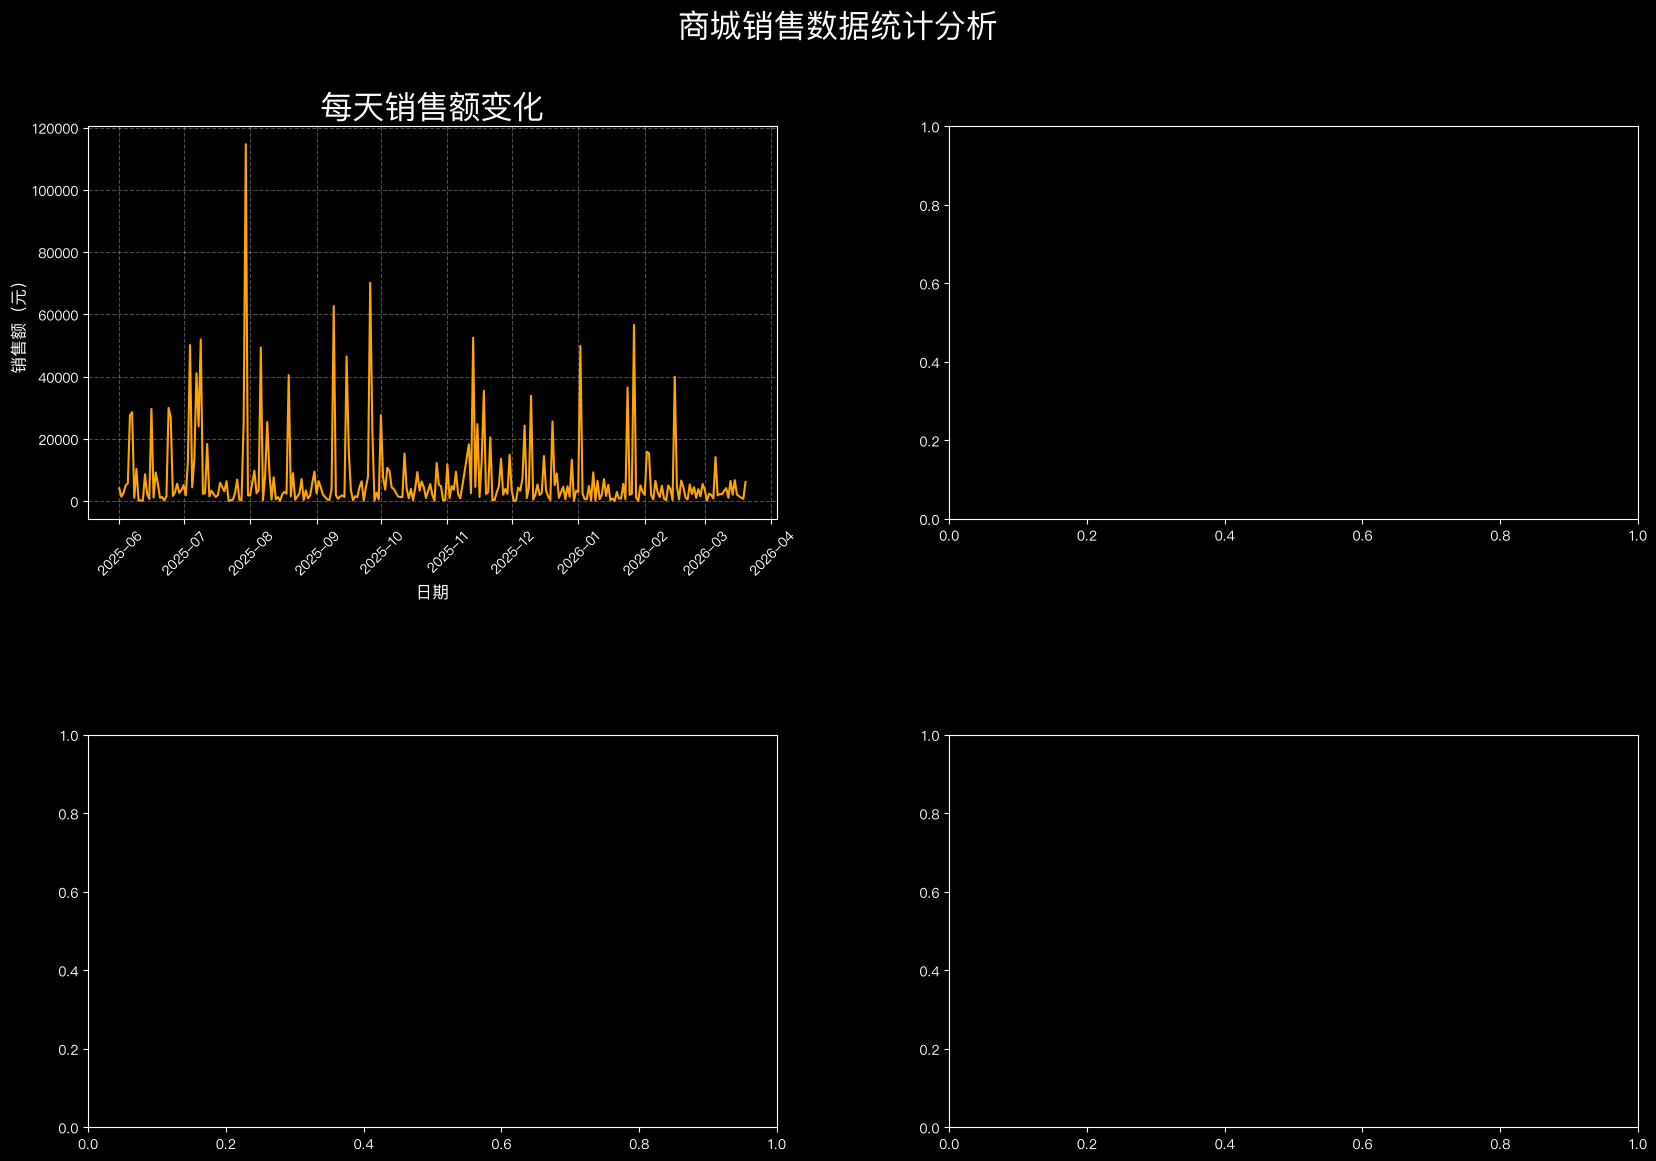

In [6]:
# 1.2 绘制折线图
axes1.plot(daily_sales.index, daily_sales.values, color='orange')
axes1.set_title('每天销售额变化', fontsize=23)
axes1.set_xlabel('日期', fontsize=12)
axes1.set_ylabel('销售额（元）', fontsize=12)
axes1.tick_params(axis='x', rotation=45)  # 日期标签旋转避免重叠
axes1.grid(linestyle='--', alpha=0.3)

display(fig)

## 2. 需求二：统计对比不同城市的累计销售数量（柱状图）

In [7]:
# 2.1 按城市分组累加销售数量（注意：是累计销售数量，不是订单数）
# 降序排列，柱子按高低自然递减更好看
city_count = data.groupby('客户所在城市')['销售数量'].sum().sort_values(ascending=False)
city_count

客户所在城市
郑州    338
天津    333
昆明    331
宁波    326
重庆    316
南京    315
福州    301
杭州    299
深圳    292
苏州    276
长沙    268
青岛    264
厦门    255
广州    247
合肥    245
北京    240
武汉    234
西安    228
成都    211
上海    211
Name: 销售数量, dtype: int64

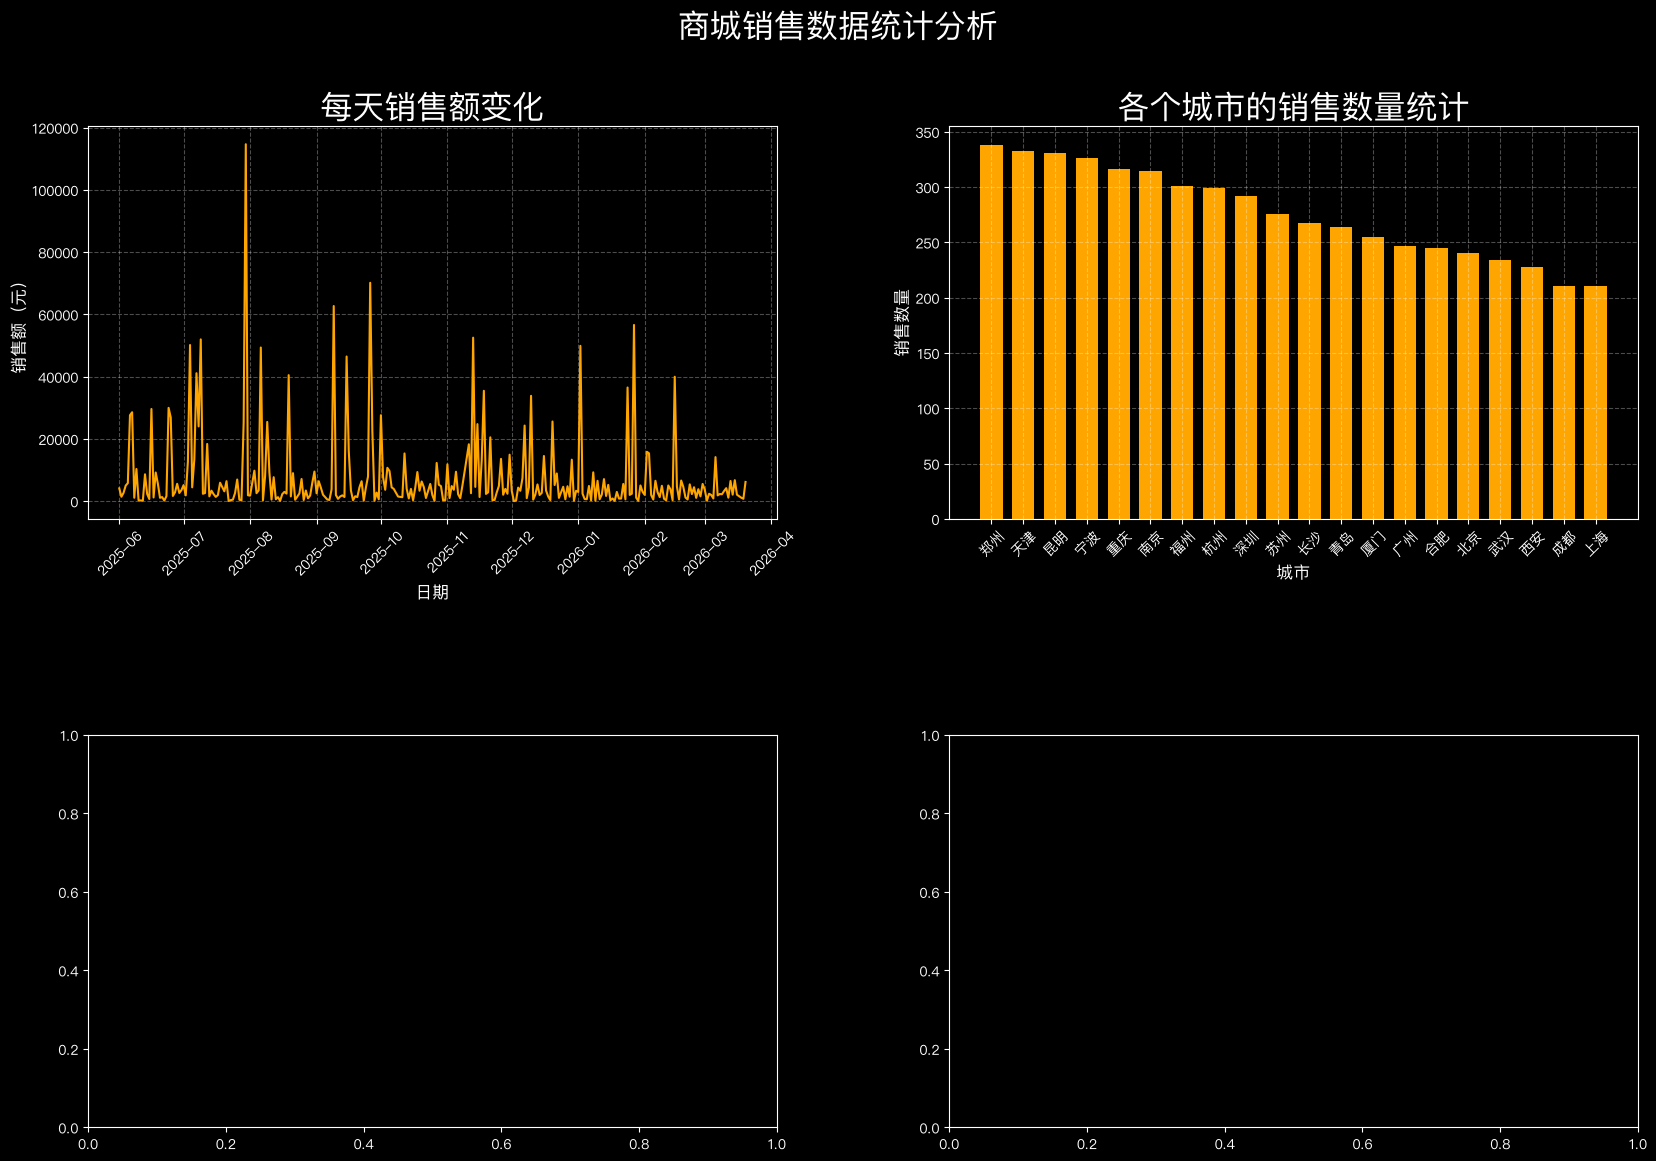

In [8]:
# 2.2 绘制柱状图
axes2.bar(city_count.index.tolist(), city_count.values.tolist(), color='orange', width=0.7)
axes2.set_title('各个城市的销售数量统计', fontsize=23)
axes2.set_xlabel('城市', fontsize=12)
axes2.set_ylabel('销售数量', fontsize=12)
axes2.grid(linestyle='--', alpha=0.3)
axes2.tick_params(axis='x', rotation=45)

display(fig)

## 3. 需求三：统计不同产品类型对应的订单比例（饼图）

In [9]:
# 3.1 value_counts() 一步搞定 "分组 + 计数 + 降序"，比 groupby().count().sort_values() 紧凑
category_count = data['产品类别'].value_counts()
category_count

产品类别
食品      212
家居用品    208
电子产品    205
服装      192
图书      182
Name: count, dtype: int64

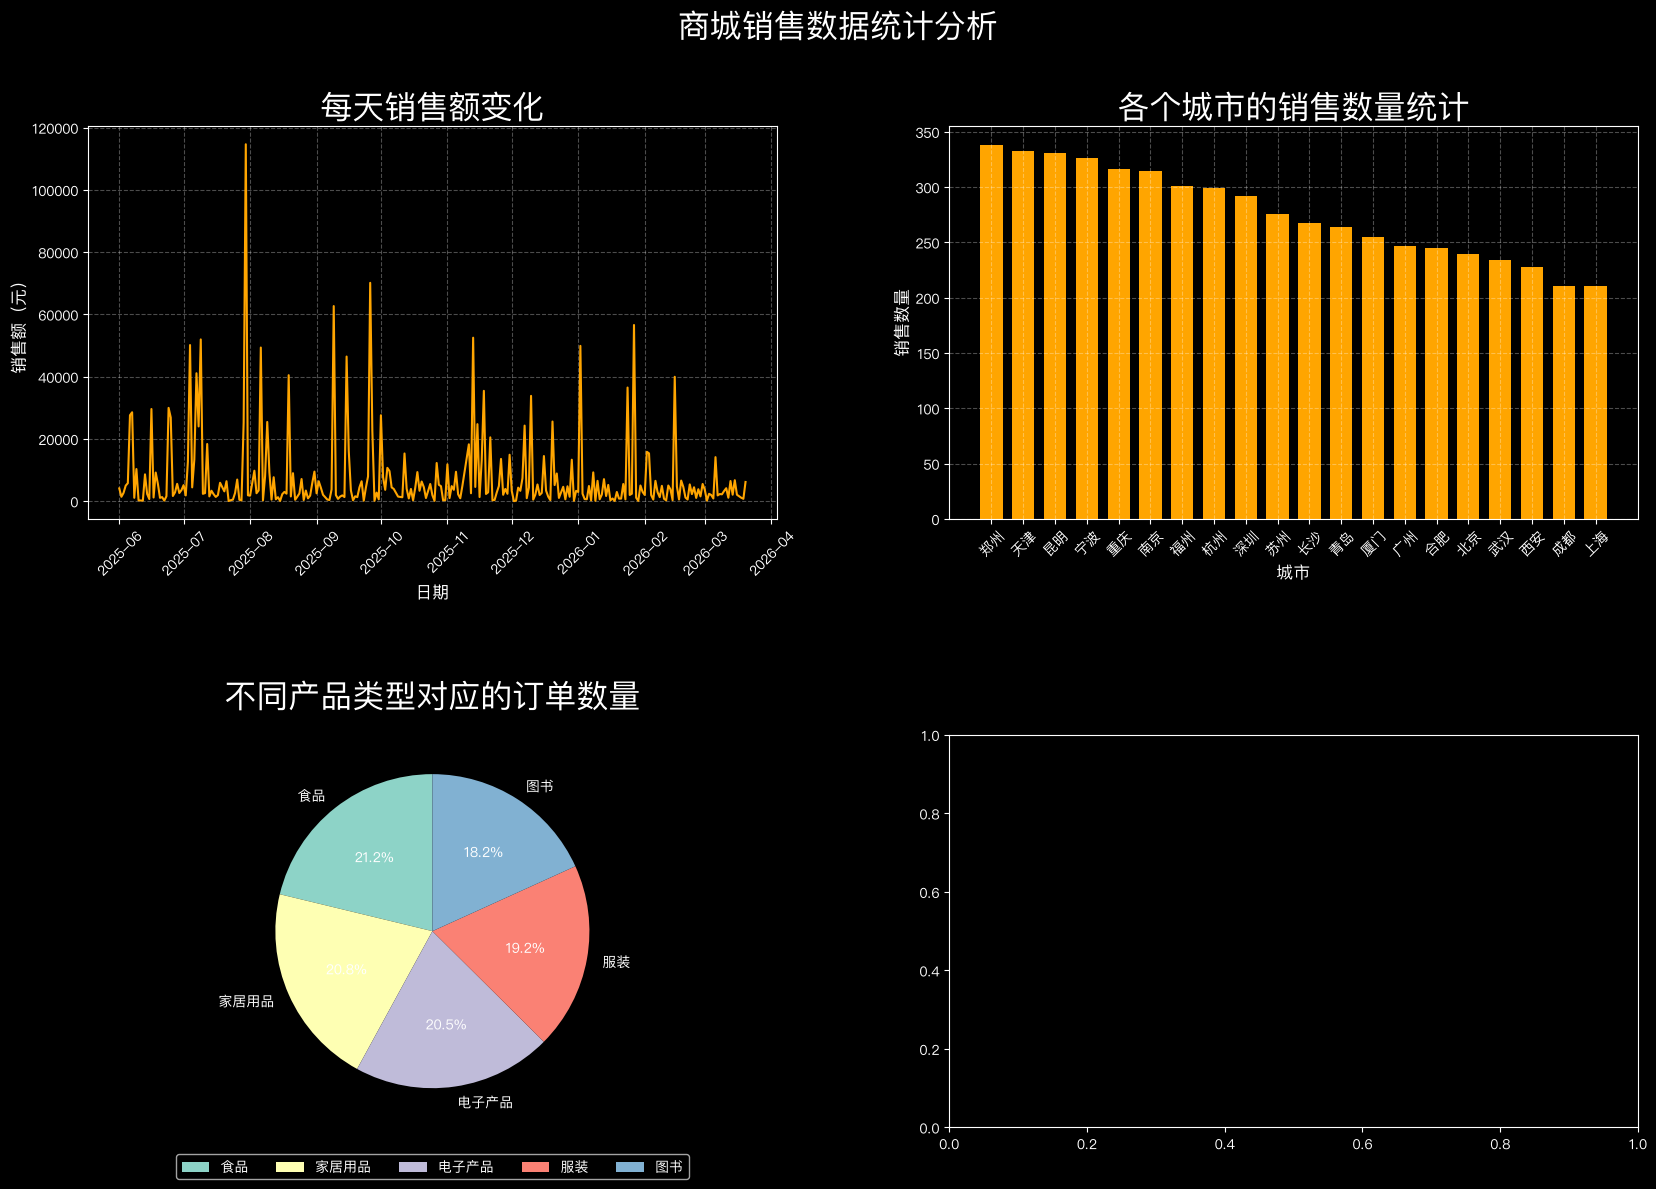

In [10]:
# 3.2 绘制饼图
axes3.clear()  # 清空旧内容，避免反复运行单元格导致饼图叠加
axes3.pie(
    category_count.values.tolist(),
    labels=category_count.index.tolist(),
    autopct='%1.1f%%',  # 自动显示百分比，1 位小数
    startangle=90,       # 从 12 点钟方向开始切
)
axes3.set_title('不同产品类型对应的订单数量', fontsize=23, pad=20)
axes3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(category_count))

display(fig)

## 4. 需求四：统计不同支付方式对应的订单比例（饼图）

In [11]:
# 4.1 同样用 value_counts()
payment_count = data['支付方式'].value_counts()
payment_count

支付方式
支付宝     434
微信支付    278
银行卡     259
现金       28
Name: count, dtype: int64

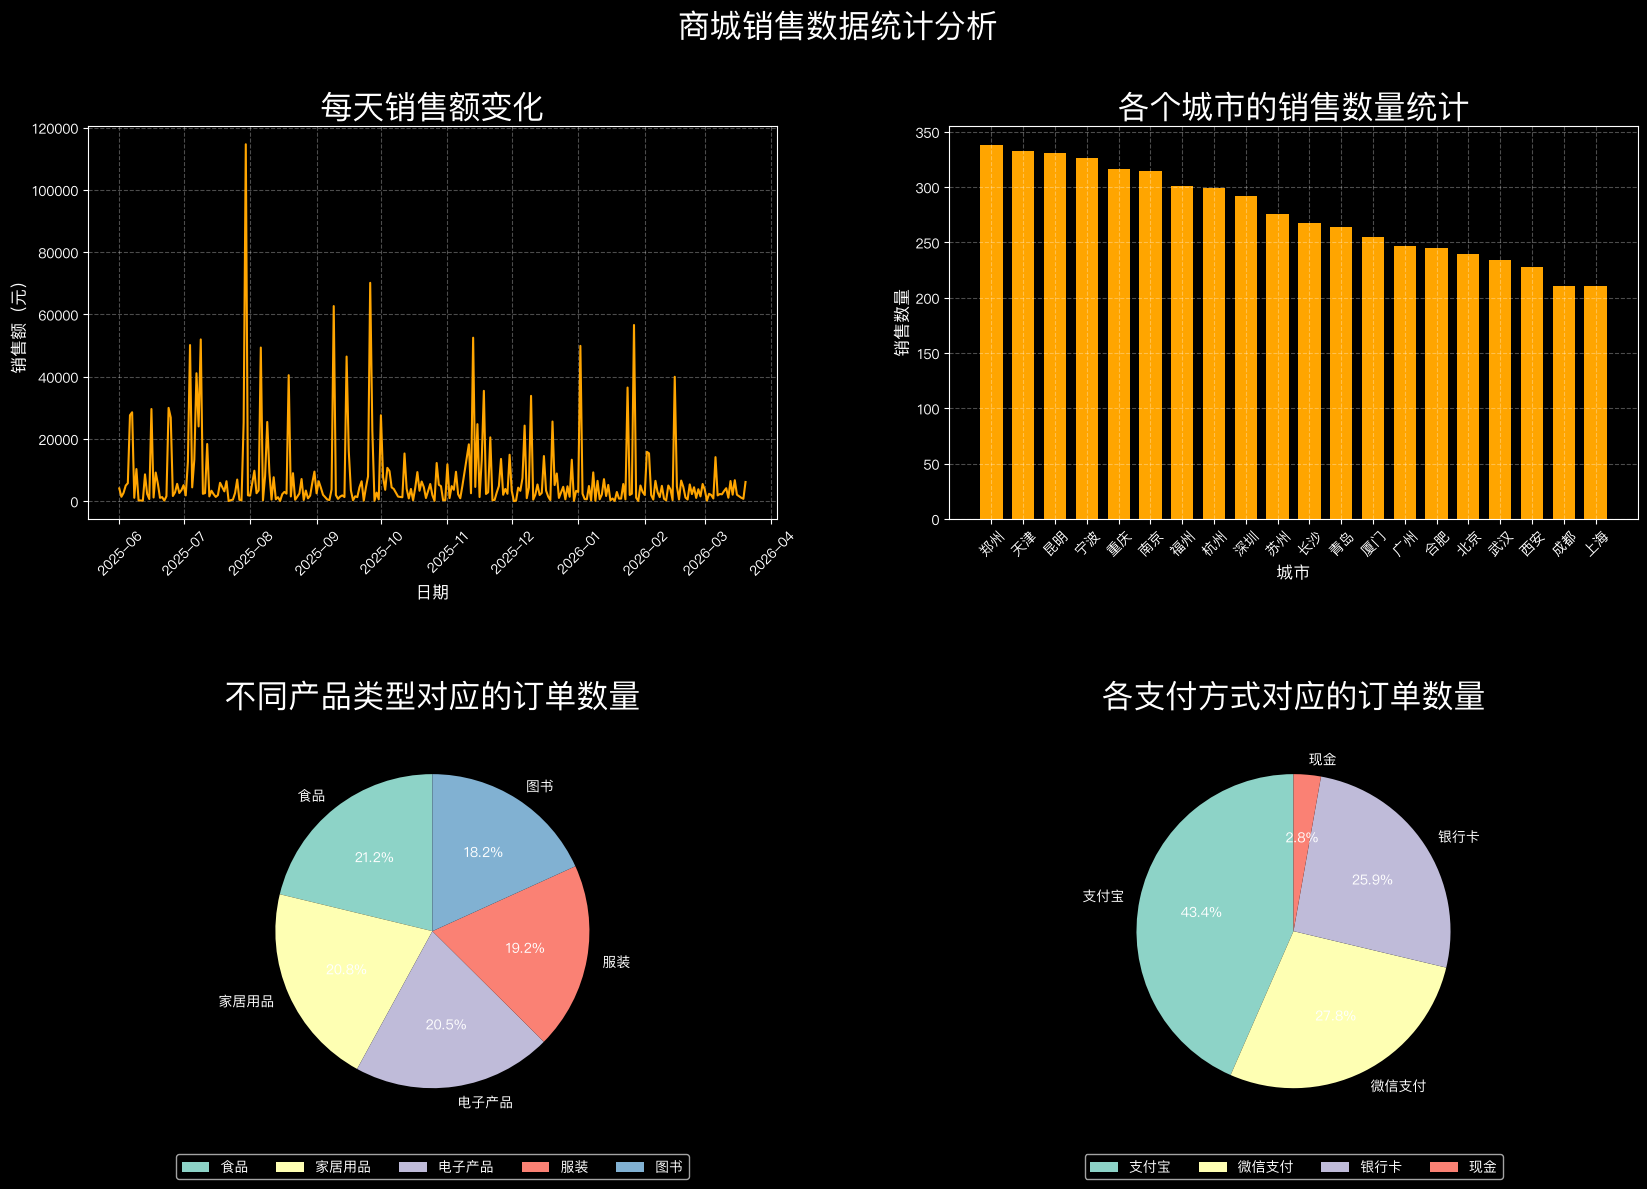

In [12]:
# 4.2 绘制饼图
axes4.clear()
axes4.pie(
    payment_count.values.tolist(),
    labels=payment_count.index.tolist(),
    autopct='%1.1f%%',
    startangle=90,
)
axes4.set_title('各支付方式对应的订单数量', fontsize=23, pad=20)
axes4.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(payment_count))

# 4.3 保存图片
fig.savefig('data/商城销售订单统计.png', dpi=300, bbox_inches='tight')

display(fig)

---

**协助署名**  
- 原始分析思路与练习需求：ethanzzhao（黑马程序员 PPT 练习）  
- 笔记整理与代码示范：Claude Opus 4.7 (1M context) — Anthropic, via Claude Code